# $z_f$ correlation vs. host mass

Same test as `zx_rho.ipynb` (Spearman $\rho$ between $N_{\rm sub}$ / $f_{\rm sub}$ and $z_f$, the redshift at which the host has assembled a fraction $f$ of its $z=0$ mass), but run separately for each of the 8 host-mass bins in `data/zhao/N500_L900/` (1000 trees each) to see how the correlation strength depends on halo mass.

$N_{\rm sub}$/$f_{\rm sub}$ use the project-standard `regime="artificial"`, `order="all"` definition (same default as `jsm_processh5.ProcessH5`) -- `Nsub_artificial_all` and `fsub_artificial_k1` (fsub has no "all" row; k1 already accounts for all its children, see `jsm_ancillary.load_massspec_z0`).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stats
import config as cfg
import matplotlib as mpl


In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [5]:
datadir = "../../data/zhao/N500_L900/"
mass_bins = ["12.6", "12.8", "13.0", "13.2", "13.4", "13.6", "13.8", "14.0"]
mass_vals = np.array([float(mb) for mb in mass_bins])

mass_fracs = np.linspace(0.01, 1.0, 100)  # f = M(z) / M(z0)


In [6]:
def find_nearest1(array, value):
    idx, val = min(enumerate(array), key=lambda x: abs(x[1] - value))
    return idx

# Function to compute zX for a single MAH: nearest zsample index where the
# host mass history crosses mass_history[0] * f, for every f in mass_fracs.
def compute_zx(mass_history):
    return np.array([cfg.zsample[find_nearest1(mass_history, mass_history[0] * mf)] for mf in mass_fracs])


For each mass bin: load the raw tree h5 (1000 trees), build the $z_f$ matrix (1000 trees $\times$ 100 mass fractions), then for each of the 100 fractions compute the jackknife Spearman correlation of $z_f$ against $N_{\rm sub}$ and $f_{\rm sub}$ at $z=0$.

In [7]:
results = {}

for mb in mass_bins:
    df = jsm_ancillary.load_sample(datadir + f"{mb}_files.h5")

    MAH  = jsm_ancillary.make_matrix(df, "MAH")
    Nsub = jsm_ancillary.make_matrix(df, "Nsub_artificial_all")[:, 0]
    fsub = jsm_ancillary.make_matrix(df, "fsub_artificial_k1")[:, 0]

    host_zx = np.apply_along_axis(compute_zx, axis=1, arr=MAH)
    host_zx = np.log10(1 + host_zx)

    Nrho = np.full(mass_fracs.shape, np.nan)
    frho = np.full(mass_fracs.shape, np.nan)
    Nrho_err = np.full(mass_fracs.shape, np.nan)
    frho_err = np.full(mass_fracs.shape, np.nan)

    for i in range(len(mass_fracs)):
        x = host_zx[:, i]

        mask = np.isfinite(x) & np.isfinite(Nsub)
        Nrho[i], Nrho_err[i], _ = jsm_stats.jackknife_correlation(x[mask], Nsub[mask])

        mask = np.isfinite(x) & np.isfinite(fsub)
        frho[i], frho_err[i], _ = jsm_stats.jackknife_correlation(x[mask], fsub[mask])

    results[mb] = dict(Nrho=Nrho, frho=frho, Nrho_err=Nrho_err, frho_err=frho_err, n_trees=MAH.shape[0])
    print(mb, "done, n_trees =", MAH.shape[0])


12.6 done, n_trees = 1000
12.8 done, n_trees = 1000
13.0 done, n_trees = 1000
13.2 done, n_trees = 1000
13.4 done, n_trees = 1000
13.6 done, n_trees = 1000
13.8 done, n_trees = 1000
14.0 done, n_trees = 1000


$\rho_S(N_{\rm sub} \mid z_f)$ and $\rho_S(f_{\rm sub} \mid z_f)$ vs. $f$, one line per host-mass bin (color = $\log M_{\rm vir}$). Note $\rho$ is undefined right at $f=1$ (every tree's own $z_f \to z=0$ there by construction, so $z_f$ has ~zero variance across the sample) -- that's why the lines spike/turn noisy as $f \to 1$, not a bug.

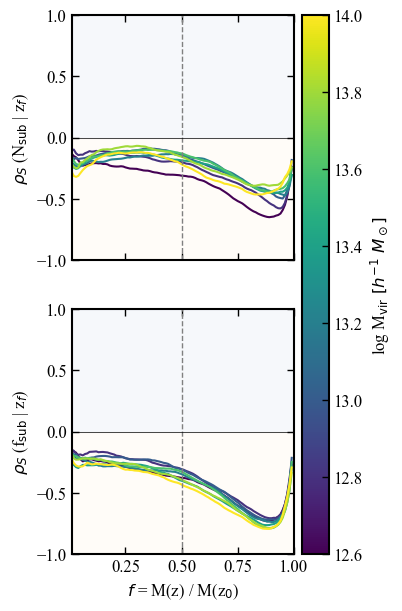

In [17]:
norm = mpl.colors.Normalize(vmin=mass_vals.min(), vmax=mass_vals.max())
cmap = mpl.cm.viridis
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(2, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

for mb, mv in zip(mass_bins, mass_vals):
    color = cmap(norm(mv))
    ax[0].plot(mass_fracs, results[mb]["Nrho"], color=color, lw=1.5)
    ax[1].plot(mass_fracs, results[mb]["frho"], color=color, lw=1.5)

ax[0].set_xlim(0.01, 1)
ax[0].set_ylim(-1, 1)

for a in ax:
    a.axvline(0.5, color="grey", ls="--", lw=1)
    a.axhline(0, color="k", lw=0.5)
    a.fill_between(mass_fracs, [0]*mass_fracs.shape[0], [1]*mass_fracs.shape[0], color="lightsteelblue", alpha=0.1)
    a.fill_between(mass_fracs, [-1]*mass_fracs.shape[0], [0]*mass_fracs.shape[0], color="bisque", alpha=0.1)

ax[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_f$)")
ax[1].set_ylabel("$\\rho_S$ (f$_{\\rm sub}$ | z$_f$)")
ax[1].set_xlabel("$f$ = M(z) / M(z$_0$)")
ax[1].set_xticks([0.25, 0.5, 0.75, 1])

cbar = fig.colorbar(sm, ax=ax, orientation="vertical", pad=0.03)
cbar.set_label("log M$_{\\rm vir}\ [h^{-1}\ M_\\odot]$")

plt.savefig("../../figures/zf_correlation_vs_mass.pdf", bbox_inches="tight")
plt.show()
